# 绘制大图

### 方法一

可以仅修改“list(df.columns[1:3]) + list(df.columns[4:5])”来绘制所需的模型的曲线

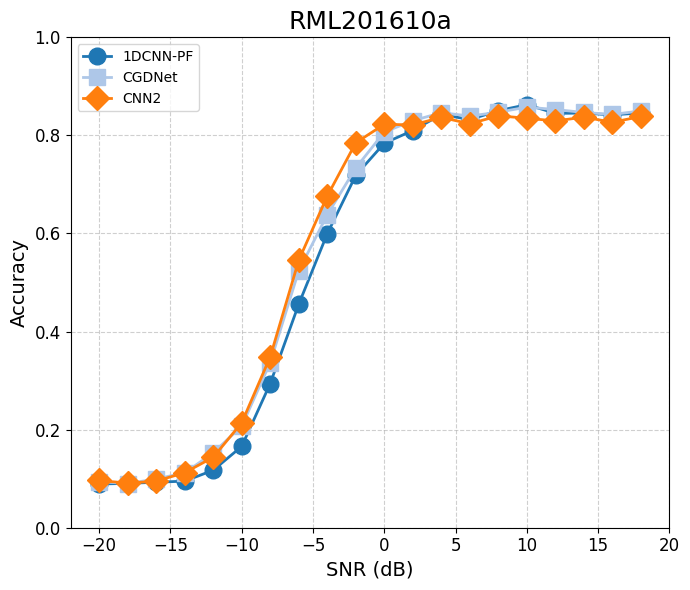

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 读取 Excel 文件
df = pd.read_excel('RML201610a.xlsx')

# 设置图像大小
plt.figure(figsize=(7, 6))

# 颜色和标记样式列表（可扩展）
markers = ['o', 's', 'D', '^', 'v', '>', '<', 'p', '*', 'h', 'H', 'x', 'd', '+', '1']
colors = plt.cm.tab20.colors  # 获取tab20色盘中的颜色

#df.columns[1:]就是全部
selected_columns = list(df.columns[1:3]) + list(df.columns[6:7])# 这里这里这里这里，修改这里可以选择模型

# 绘制每条线
for idx, column in enumerate(selected_columns):  
    plt.plot(
        df['SNR'],
        df[column],
        label=column,
        marker=markers[idx % len(markers)],
        color=colors[idx % len(colors)],  # 使用循环索引选择颜色
        linewidth=2,
        markersize=12
    )

# 设置横轴最大值为 20
plt.xlim(-22, 20)
plt.ylim(0, 1)

# 设置较小的网格间隔
plt.grid(True, which='both', linestyle='--', alpha=0.6)

# 调整坐标轴刻度的间隔
plt.xticks(range(-20, 21, 5), fontsize=12)  # X轴每隔2个单位显示一个刻度
plt.yticks(fontsize=12)  # Y轴刻度字体大小

# 添加标签和标题
plt.title('RML201610a', fontsize=18)
plt.xlabel('SNR (dB)', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)

# 图例和布局调整
plt.legend(fontsize=10, loc='upper left', ncol=1)
plt.tight_layout()

# 显示图像
plt.show()


### 方法二

修改变量**columns_to_plot**指定模型曲线

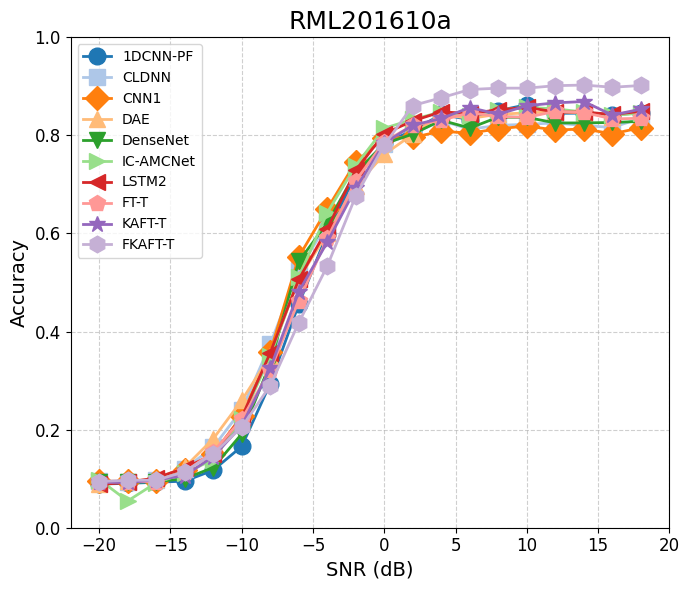

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

# 读取 Excel 文件
df = pd.read_excel('RML201610a.xlsx')

# 你可以在这里指定想画的列（列名必须和Excel文件中一致）
# '1DCNN-PF', 'CGDNet', 'CLDNN', 'CLDNN2', 'CNN1', 'CNN2', 'DAE'
# 'DenseNet', 'GRU2', 'IC-AMCNet', 'LSTM2', 'MCLDNN', 'MCNET', 'PET-CGDNN', 'ResNet'
columns_to_plot = ['1DCNN-PF','CLDNN','CNN1','DAE','DenseNet','IC-AMCNet','LSTM2','FT-T','KAFT-T','FKAFT-T']  # 举例，可根据你的文件更改

# 设置图像大小
plt.figure(figsize=(7, 6))

# 样式列表
markers = ['o', 's', 'D', '^', 'v', '>', '<', 'p', '*', 'h', 'H', 'x', 'd', '+', '1']
colors = plt.cm.tab20.colors

# 绘图
for idx, column in enumerate(columns_to_plot):
    if column not in df.columns:
        print(f"警告：列名 '{column}' 不在 Excel 文件中，已跳过。")
        continue
    plt.plot(
        df['SNR'],
        df[column],
        label=column,
        marker=markers[idx % len(markers)],
        color=colors[idx % len(colors)],
        linewidth=2,
        markersize=12
    )

# 轴、网格、标签设置
plt.xlim(-22, 20)
plt.ylim(0, 1)
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.xticks(range(-20, 21, 5), fontsize=12)
plt.yticks(fontsize=12)
plt.title('RML201610a', fontsize=18)
plt.xlabel('SNR (dB)', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)
plt.legend(fontsize=10, loc='upper left', ncol=1)
plt.tight_layout()

plt.show()


# 绘制小图

注意本代码需要读取xlsx文件只有SNR为0~18的数值

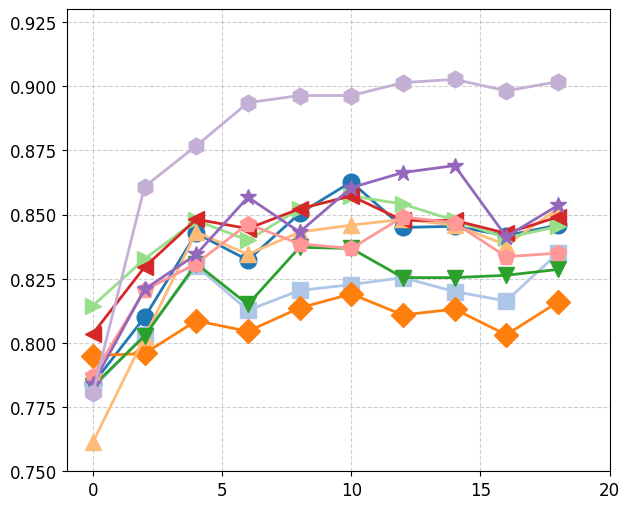

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import math

# 读取 Excel 文件
df = pd.read_excel('RML201610a.xlsx')
df = df[df['SNR'] >= 0]
# 设置图像大小
plt.figure(figsize=(7, 6))

# 颜色和标记样式列表（可扩展）
markers = ['o', 's', 'D', '^', 'v', '>', '<', 'p', '*', 'h', 'H', 'x', 'd', '+', '1']
colors = plt.cm.tab20.colors  # 获取tab20色盘中的颜色


for idx, column in enumerate(columns_to_plot):  # 第一个是 SNR
    plt.plot(
        df['SNR'],
        df[column],
        label=column,
        marker=markers[idx % len(markers)],
        color=colors[idx % len(colors)],  # 使用循环索引选择颜色
        linewidth=2,
        markersize=12
    )

# 设置横轴最大值为 20
plt.xlim(-1, 20)
plt.ylim((math.floor(df.iloc[:, 1:].min().min() * 100) / 100) - 0.01, (math.floor(df.iloc[:, 1:].max().max() * 100) / 100) + 0.01)

# 设置较小的网格间隔
plt.grid(True, which='both', linestyle='--', alpha=0.6)

# 调整坐标轴刻度的间隔
plt.xticks(range(0, 21, 5), fontsize=12)  # X轴每隔2个单位显示一个刻度
plt.yticks(fontsize=12)  # Y轴刻度字体大小

# 添加标签和标题
# plt.title('RML201610a', fontsize=18)
# plt.xlabel('SNR (dB)', fontsize=14)
# plt.ylabel('Accuracy', fontsize=14)

# 显示图像
plt.show()


/tmp/ipykernel_922638/923720746.py:125: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


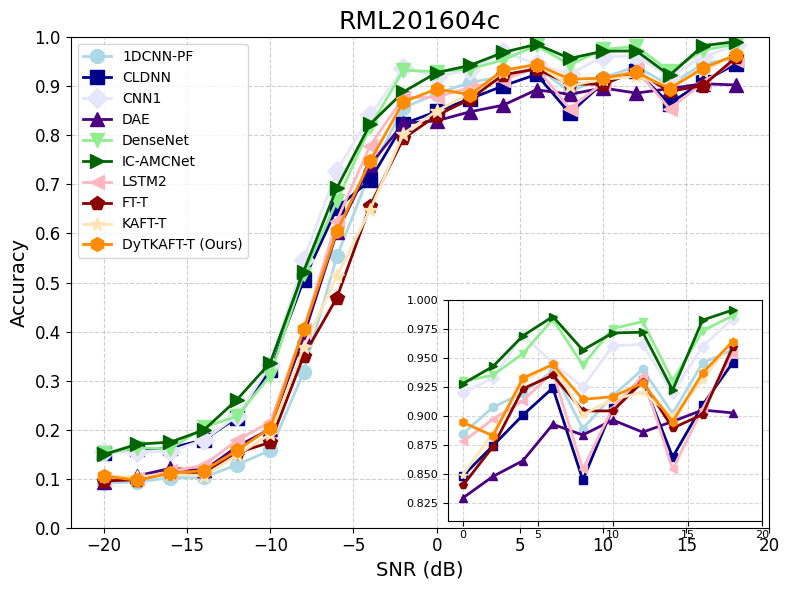

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import math

dataset_name = 'RML201604c'
# 读取 Excel 文件
df = pd.read_excel(f'{dataset_name}.xlsx')

# 只取SNR>=0的数据用于绘制
df_positive = df[df['SNR'] >= 0]

# 要绘制的列名
columns_to_plot = ['1DCNN-PF','CLDNN','CNN1','DAE','DenseNet','IC-AMCNet','LSTM2','FT-T','KAFT-T','DyTKAFT-T']

# ---------- 图例显示名映射 ----------
legend_map = {
    'DyTKAFT-T': 'DyTKAFT-T (Ours)',
    # 其余不改的列名默认保持原样
}

# 设置图像大小
fig, ax = plt.subplots(figsize=(8, 6))

# 颜色    浅色 HEX   深色 HEX
# 蓝色    '#ADD8E6','#00008B'
# 绿色    '#90EE90','#006400'
# 红色    '#FFB6C1','#8B0000'
# 黄色    '#FFFFE0','#FFD700'
# 青色    '#E0FFFF','#00CED1'
# 紫色    '#E6E6FA','#4B0082'
# 橙色    '#FFE4B5','#FF8C00'
# 棕色    '#F5DEB3','#8B4513'
# 灰色    '#D3D3D3','#696969'
# 粉色    '#FFCCE5','#C71585'
# 橄榄绿  '#F0FFF0','#556B2F'
# 海蓝    '#B0E0E6','#4682B4'
# 酒红    '#FFE4E1','#800000'
# 金色    '#FFF8DC','#B8860B'
# 靛青    '#F0F8FF','#191970'

# 颜色列表（浅深浅深交替）
base_colors = [
    '#ADD8E6', '#00008B',  
    '#E6E6FA', '#4B0082',  
    '#90EE90', '#006400',  
    '#FFB6C1', '#8B0000',  
    '#FFE4B5', '#FF8C00',  
]

# 标记样式
markers = ['o', 's', 'D', '^', 'v', '>', '<', 'p', '*', 'h', 'H', 'x', 'd', '+', '1']

for idx, column in enumerate(columns_to_plot):
    if column not in df.columns:
        print(f"警告：列名 '{column}' 不在 Excel 文件中，已跳过。")
        continue

    # 默认按交替浅深颜色
    color = base_colors[idx % len(base_colors)]
    label_txt = legend_map.get(column, column)   # 关键：映射图例文字

    # # 特殊处理指定曲线
    # if column == 'KAFT-T':
    #     color = '#FFFACD'  # 浅黄色 (LemonChiffon)
    # elif column == 'FKAFT-T':
    #     color = '#FFFF00'  # 亮黄色 (Yellow)

    ax.plot(
        df['SNR'],
        df[column],
        label=label_txt,
        marker=markers[idx % len(markers)],
        color=color,
        linewidth=2,
        markersize=10
    )

# 主图设置
ax.set_xlim(-22, 20)
ax.set_ylim(0, 1)
ax.grid(True, which='both', linestyle='--', alpha=0.6)
ax.set_xticks(range(-20, 21, 5))
ax.set_yticks([i/10 for i in range(0, 11)])
ax.tick_params(labelsize=12)
ax.set_title(f'{dataset_name}', fontsize=18)
ax.set_xlabel('SNR (dB)', fontsize=14)
ax.set_ylabel('Accuracy', fontsize=14)

# 添加大图的图例
ax.legend(fontsize=10, loc='upper left', ncol=1)

# 添加小图（放大局部，SNR>0部分）
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

axins = inset_axes(ax, width="45%", height="45%", loc='lower right')  # 小图位置

for idx, column in enumerate(columns_to_plot):
    if column not in df.columns:
        continue

    color = base_colors[idx % len(base_colors)]
    # if column == 'KAFT-T':
    #     color = '#FFFACD'  # 浅黄色
    # elif column == 'FKAFT-T':
    #     color = '#FFFF00'  # 亮黄色

    axins.plot(
        df_positive['SNR'],
        df_positive[column],
        marker=markers[idx % len(markers)],
        color=color,
        linewidth=2,
        markersize=6
    )

axins.set_xlim(-1, 20)
ymin = math.floor(df_positive.iloc[:, 1:].min().min() * 100) / 100 - 0.01
ymax = math.floor(df_positive.iloc[:, 1:].max().max() * 100) / 100 + 0.01
axins.set_ylim(ymin, ymax)
axins.grid(True, linestyle='--', alpha=0.5)
axins.set_xticks(range(0, 21, 5))
axins.tick_params(labelsize=8)

# 调整整体布局
plt.tight_layout()
plt.savefig(f'result/{dataset_name}.png')
plt.savefig(f'result/{dataset_name}.svg', format="svg")
plt.show()
